## How does a matrix transformation work ?
***
Matrix is a linear transfomation that can be applied on various items like vector, array, shapes etc. Essentially it transforms the space in which the item, that it is applied to, lies. It essentially can rotate, flip, stretch, shrink or apply combinations of them to create a new transformation. 

***
Below is a example of how matrix transformation affects a circle and a square.

##### **Circle**

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


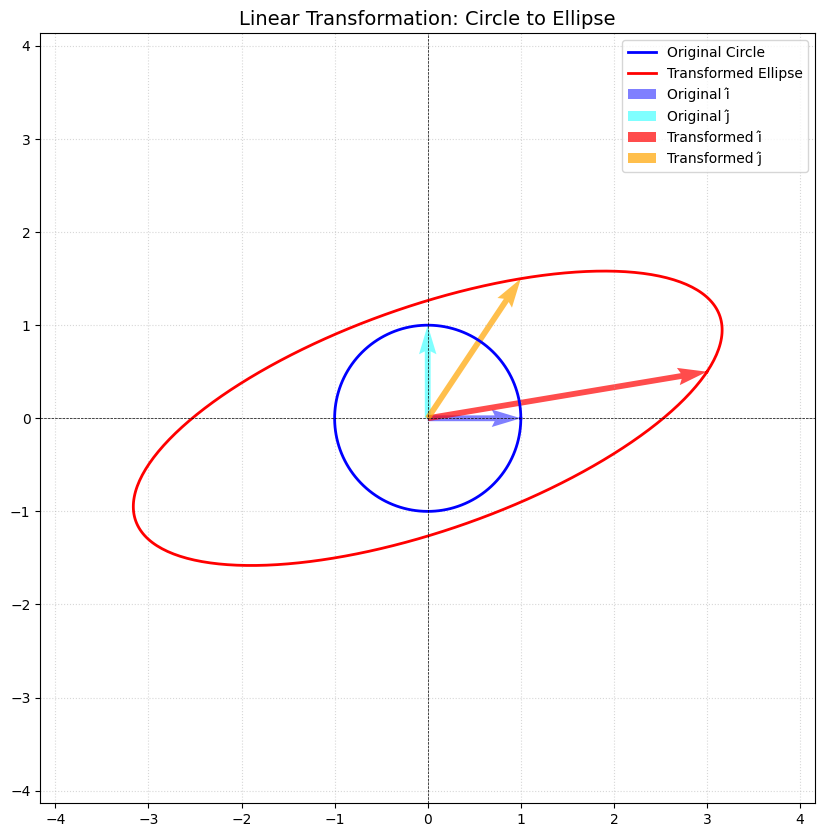

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_matrix_transformation():
    # 1. Generate points for a unit circle
    theta = np.linspace(0, 2 * np.pi, 300)
    # x and y coordinates of the circle
    x = np.cos(theta)
    y = np.sin(theta)
    
    # Combine into a 2xN matrix where each column is a 2D point vector
    circle_points = np.vstack((x, y))

    # 2. Define the transformation matrix (A)
    # This matrix scales the x-axis by 3, scales the y-axis by 1.5,
    # and introduces a shear to rotate/stretch it dynamically.
    A = np.array([
        [3.0, 1.0],
        [0.5, 1.5]
    ])

    # 3. Apply the transformation via matrix multiplication
    # New_Points = A * Old_Points
    transformed_points = np.dot(A, circle_points)

    # 4. Plotting the results
    plt.figure(figsize=(10, 10))
    
    # Plot original circle
    plt.plot(circle_points[0, :], circle_points[1, :], 
             label='Original Circle', color='blue', linewidth=2)
    
    # Plot transformed ellipse
    plt.plot(transformed_points[0, :], transformed_points[1, :], 
             label='Transformed Ellipse', color='red', linewidth=2)
    
    # Plot basis vectors to show how space itself distorted
    # Original basis vectors
    plt.quiver(0, 0, 1, 0, angles='xy', scale_units='xy', scale=1, color='blue', alpha=0.5, label='Original î')
    plt.quiver(0, 0, 0, 1, angles='xy', scale_units='xy', scale=1, color='cyan', alpha=0.5, label='Original ĵ')
    
    # Transformed basis vectors (these are just the columns of matrix A!)
    plt.quiver(0, 0, A[0,0], A[1,0], angles='xy', scale_units='xy', scale=1, color='red', alpha=0.7, label='Transformed î')
    plt.quiver(0, 0, A[0,1], A[1,1], angles='xy', scale_units='xy', scale=1, color='orange', alpha=0.7, label='Transformed ĵ')

    # Formatting the plot
    plt.axhline(0, color='black',linewidth=0.5, linestyle='--')
    plt.axvline(0, color='black',linewidth=0.5, linestyle='--')
    plt.grid(True, which='both', linestyle=':', alpha=0.5)
    
    # Equal scaling ensures circles don't look like ellipses due to screen stretching
    plt.axis('equal') 
    
    # Dynamic limits based on transformation
    max_val = np.max(np.abs(transformed_points)) + 1
    plt.xlim(-max_val, max_val)
    plt.ylim(-max_val, max_val)
    
    plt.title('Linear Transformation: Circle to Ellipse', fontsize=14)
    plt.legend(loc='upper right')
    plt.show()

if __name__ == "__main__":
    simulate_matrix_transformation()

##### **Square**

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


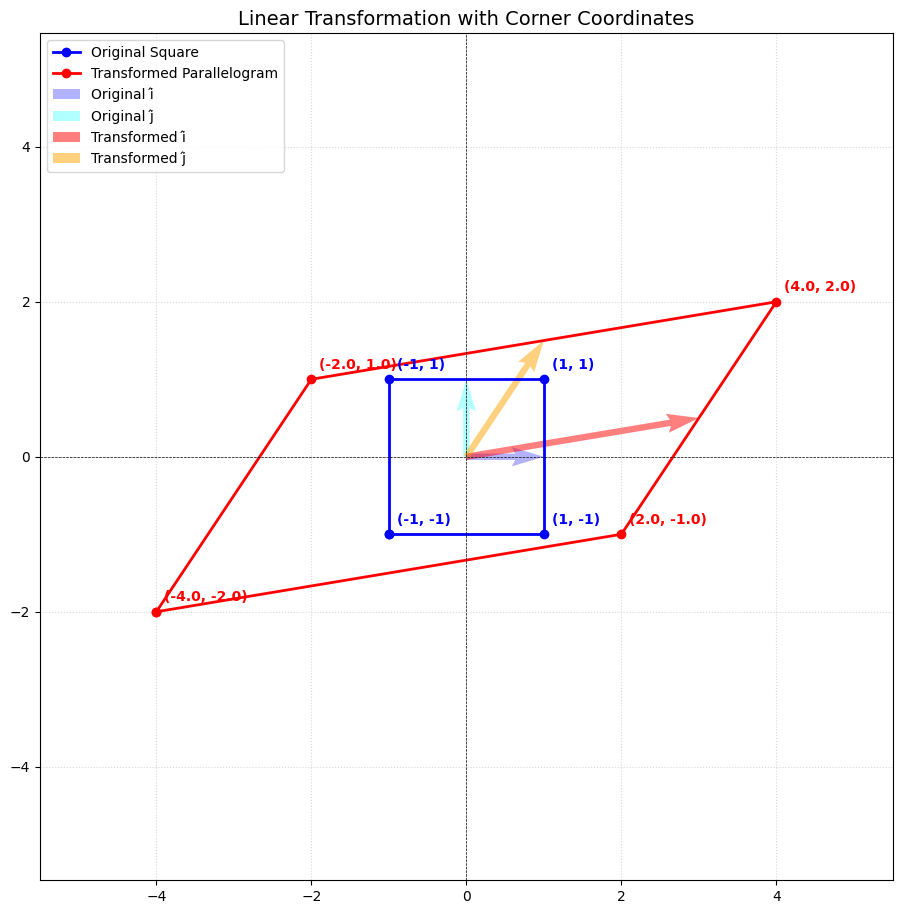

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_square_with_coordinates():
    # 1. Generate points for a unit square
    # 4 corners, closing the loop by repeating the first corner
    x = np.array([-1,  1,  1, -1, -1])
    y = np.array([-1, -1,  1,  1, -1])
    
    square_points = np.vstack((x, y))

    # 2. Define the transformation matrix (A)
    A = np.array([
        [3.0, 1.0],
        [0.5, 1.5]
    ])

    # 3. Apply the transformation via matrix multiplication
    transformed_points = np.dot(A, square_points)

    # 4. Plotting the results
    plt.figure(figsize=(11, 11))
    
    # Plot original square
    plt.plot(square_points[0, :], square_points[1, :], 
             label='Original Square', color='blue', linewidth=2, marker='o')
    
    # Plot transformed parallelogram
    plt.plot(transformed_points[0, :], transformed_points[1, :], 
             label='Transformed Parallelogram', color='red', linewidth=2, marker='o')
    
    # 5. Annotate coordinates on the graph
    # We only loop through the first 4 points (ignoring the 5th closing point)
    for i in range(4):
        # Original square coordinates (Blue text)
        orig_x, orig_y = square_points[0, i], square_points[1, i]
        plt.text(orig_x + 0.1, orig_y + 0.1, f'({orig_x}, {orig_y})', 
                 color='blue', fontsize=10, fontweight='bold',
                 ha='left', va='bottom')
        
        # Transformed coordinates (Red text)
        trans_x, trans_y = transformed_points[0, i], transformed_points[1, i]
        plt.text(trans_x + 0.1, trans_y + 0.1, f'({trans_x:.1f}, {trans_y:.1f})', 
                 color='red', fontsize=10, fontweight='bold',
                 ha='left', va='bottom')

    # Plot basis vectors
    plt.quiver(0, 0, 1, 0, angles='xy', scale_units='xy', scale=1, color='blue', alpha=0.3, label='Original î')
    plt.quiver(0, 0, 0, 1, angles='xy', scale_units='xy', scale=1, color='cyan', alpha=0.3, label='Original ĵ')
    plt.quiver(0, 0, A[0,0], A[1,0], angles='xy', scale_units='xy', scale=1, color='red', alpha=0.5, label='Transformed î')
    plt.quiver(0, 0, A[0,1], A[1,1], angles='xy', scale_units='xy', scale=1, color='orange', alpha=0.5, label='Transformed ĵ')

    # Formatting
    plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
    plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
    plt.grid(True, which='both', linestyle=':', alpha=0.5)
    plt.axis('equal') 
    
    max_val = np.max(np.abs(transformed_points)) + 1.5
    plt.xlim(-max_val, max_val)
    plt.ylim(-max_val, max_val)
    
    plt.title('Linear Transformation with Corner Coordinates', fontsize=14)
    plt.legend(loc='upper left')
    plt.show()

if __name__ == "__main__":
    simulate_square_with_coordinates()